# Continuous State Discretization using VQ-VAE & Action Masking Analysis

This notebook demonstrates:
1. **Environment Setup & Data Collection**: Sampling continuous state-action trajectories from a Gymnasium/MuJoCo environment (`Pendulum-v1` / `InvertedPendulum-v4`).
2. **VQ-VAE Architecture**: Discretizing continuous state vector $s \in \mathbb{R}^d$ into a discrete codebook index $k \in \{0, \dots, K-1\}$.
3. **Training & Codebook Evaluation**: Training VQ-VAE to minimize reconstruction error while monitoring codebook utilization/perplexity.
4. **Visualization**: Plotting state space partitioning (e.g., Phase Space: Position vs. Velocity) colored by discrete cluster assignment.
5. **Action Masking for State Retention**: Computing action masks $M(k, a)$ that filter actions to keep the environment in the same discrete state $k$ ($s_{t+1} \to k$).

### Cell 1: Imports & Setup

In [111]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Cell 2: Continuous Environment Initialization & Trajectory Dataset Collection

In [112]:
# Initialize continuous environment (Try MuJoCo InvertedPendulum-v4 or fallback to Pendulum-v1)
ENV_NAME = 'Hopper-v4'  

env = gym.make(ENV_NAME)
print(f"Successfully initialized Gymnasium environment: {ENV_NAME}")
# except Exception as e:
#     print(f"Fallback to Pendulum-v1 due to error: {e}")
#     ENV_NAME = 'Pendulum-v1'
#     env = gym.make(ENV_NAME)

state_space = env.observation_space
action_space = env.action_space
action_low = env.action_space.low
action_high = env.action_space.high


print(f"State Space : {state_space}, Action Space : {action_space}")
print(f"Action Limits: Min = {action_low}, Max = {action_high}")


Successfully initialized Gymnasium environment: Hopper-v4
State Space : Box(-inf, inf, (11,), float64), Action Space : Box(-1.0, 1.0, (3,), float32)
Action Limits: Min = [-1. -1. -1.], Max = [1. 1. 1.]


In [113]:
# # Print textual breakdown of state and action space components
# if ENV_NAME == 'Pendulum-v1':
#     state_desc = [
#         "State[0]: cos(theta) - Cosine of pendulum angle (-1.0 to 1.0, where theta=0 is upright)",
#         "State[1]: sin(theta) - Sine of pendulum angle (-1.0 to 1.0)",
#         "State[2]: theta_dot  - Angular velocity of pendulum (-8.0 to 8.0 rad/s)"
#     ]
#     action_desc = [
#         "Action[0]: Joint Torque / Effort applied to pivot (-2.0 to +2.0 N m)"
#     ]

In [114]:
# print(state_desc)
# print(action_desc)

In [ ]:

# Collect trajectory samples (states, actions, next_states)
NUM_SAMPLES = 25000
states = []
actions = []
next_states = []

obs, _ = env.reset(seed=SEED)
for _ in range(NUM_SAMPLES):
    # Random policy action sampling with small bias to cover state space
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    
    states.append(obs)
    actions.append(action)
    next_states.append(next_obs)
    
    if terminated or truncated:
        obs, _ = env.reset()
    else:
        obs = next_obs

states_np = np.array(states, dtype=np.float32)
actions_np = np.array(actions, dtype=np.float32)
#next_states_np = np.array(next_states, dtype=np.float32)

# Compute normalization stats for state space
state_mean = torch.tensor(states_np.mean(axis=0), dtype=torch.float32)
state_std = torch.tensor(states_np.std(axis=0) + 1e-6, dtype=torch.float32)

states_tensor = torch.tensor(states_np, dtype=torch.float32)
states_normalized = (states_tensor - state_mean) / state_std

dataset = TensorDataset(states_normalized)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print(f"Dataset collected: {len(states_tensor)} samples.")
print(f"State Means: {state_mean.numpy()}")
print(f"State Stds:  {state_std.numpy()}")

Dataset collected: 25000 samples.
State Means: [ 1.2229275  -0.05927672 -0.04332874 -0.06239989  0.05124104 -0.13745852
 -0.24525242 -1.0898075  -0.77334    -0.8417519   0.5076794 ]
State Stds:  [0.02766237 0.0635002  0.07077964 0.1040563  0.1554496  0.40810758
 0.29868966 1.3875407  1.4659665  1.4980769  1.7114316 ]


### Cell 3: VQ-VAE Architecture for State Space Discretization

In [ ]:
class VectorQuantizer(nn.Module):
    """
    Vector Quantization Layer mapping continuous embeddings to discrete codebook vectors.
    """
    def __init__(self, num_embeddings=32, embedding_dim=16, commitment_cost=0.25):
        super(VectorQuantizer, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        
        # Codebook storage
        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.num_embeddings, 1.0 / self.num_embeddings)
        
    def forward(self, inputs):
        # inputs shape: (batch_size, embedding_dim)
        # Calculate Euclidean distances between inputs and codebook embeddings
        distances = (torch.sum(inputs**2, dim=1, keepdim=True) 
                     + torch.sum(self.embedding.weight**2, dim=1)
                     - 2 * torch.matmul(inputs, self.embedding.weight.t()))
            
        # Find closest codebook indices
        encoding_indices = torch.argmin(distances, dim=1)
        quantized = self.embedding(encoding_indices)
        
        # VQ Losses
        e_latent_loss = F.mse_loss(quantized.detach(), inputs)  # Vector quantization loss
        q_latent_loss = F.mse_loss(quantized, inputs.detach())  # Commitment loss
        loss = q_latent_loss + self.commitment_cost * e_latent_loss
        
        # Straight-Through Estimator (STE)
        quantized = inputs + (quantized - inputs).detach()
        
        # Compute Codebook Perplexity (utilization metric)
        encodings = F.one_hot(encoding_indices, self.num_embeddings).float()
        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        
        return quantized, loss, encoding_indices, perplexity

class VQVAEStateDiscretizer(nn.Module):
    """
    VQ-VAE Architecture for discretizing continuous state spaces.
    """
    def __init__(self, state_dim, hidden_dim=64, embedding_dim=16, num_embeddings=32, commitment_cost=0.25):
        super(VQVAEStateDiscretizer, self).__init__()
        
        # Continuous State Encoder
        self.encoder = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )
        
        # Vector Quantizer Codebook
        self.vq_layer = VectorQuantizer(num_embeddings, embedding_dim, commitment_cost)
        
        # Continuous State Decoder
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )
        
    def forward(self, state):
        z_e = self.encoder(state)
        z_q, vq_loss, encoding_indices, perplexity = self.vq_layer(z_e)
        state_recon = self.decoder(z_q)
        return state_recon, vq_loss, encoding_indices, perplexity

    def encode_to_discrete(self, state):
        z_e = self.encoder(state)
        _, _, encoding_indices, _ = self.vq_layer(z_e)
        return encoding_indices

# Instantiate Model
NUM_EMBEDDINGS = 64   # Number of discrete states (clusters)
EMBEDDING_DIM = 16   # Dimension of codebook vectors

state_dim=states_np.shape[1]

vqvae_model = VQVAEStateDiscretizer(
    state_dim=state_dim,
    hidden_dim=64,
    embedding_dim=EMBEDDING_DIM,
    num_embeddings=NUM_EMBEDDINGS,
    commitment_cost=0.25
).to(device)

print(vqvae_model)

VQVAEStateDiscretizer(
  (encoder): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=16, bias=True)
  )
  (vq_layer): VectorQuantizer(
    (embedding): Embedding(64, 16)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=11, bias=True)
  )
)


### Cell 4: Training VQ-VAE State Discretizer

Epoch [01/40] | Total Loss: 9.00115 | Recon MSE: 0.86101 | VQ Loss: 8.14015 | Codebook Perplexity: 6.92/64
Epoch [05/40] | Total Loss: 5.31232 | Recon MSE: 0.60614 | VQ Loss: 4.70619 | Codebook Perplexity: 6.26/64
Epoch [10/40] | Total Loss: 4.57948 | Recon MSE: 0.52171 | VQ Loss: 4.05777 | Codebook Perplexity: 7.77/64
Epoch [15/40] | Total Loss: 3.53981 | Recon MSE: 0.46223 | VQ Loss: 3.07758 | Codebook Perplexity: 10.97/64
Epoch [20/40] | Total Loss: 2.64571 | Recon MSE: 0.42364 | VQ Loss: 2.22207 | Codebook Perplexity: 13.26/64
Epoch [25/40] | Total Loss: 2.25203 | Recon MSE: 0.38353 | VQ Loss: 1.86850 | Codebook Perplexity: 15.73/64
Epoch [30/40] | Total Loss: 1.93761 | Recon MSE: 0.36179 | VQ Loss: 1.57582 | Codebook Perplexity: 18.44/64
Epoch [35/40] | Total Loss: 1.84229 | Recon MSE: 0.34860 | VQ Loss: 1.49369 | Codebook Perplexity: 20.80/64
Epoch [40/40] | Total Loss: 1.57998 | Recon MSE: 0.33673 | VQ Loss: 1.24325 | Codebook Perplexity: 21.94/64


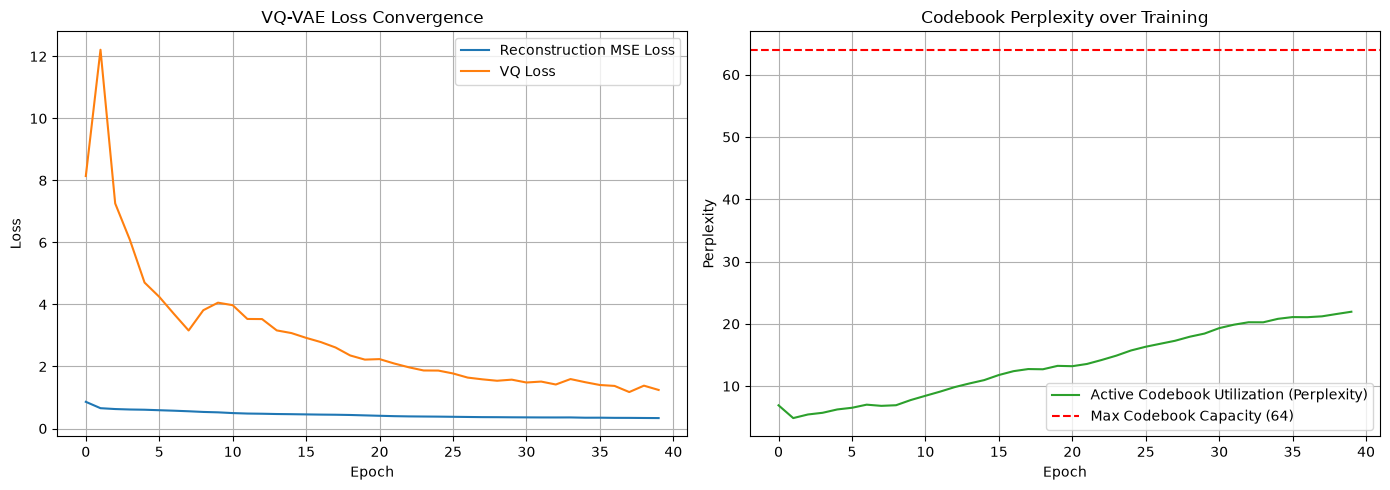

In [117]:
optimizer = torch.optim.Adam(vqvae_model.parameters(), lr=1e-3)
EPOCHS = 40

loss_history = []
recon_loss_history = []
vq_loss_history = []
perplexity_history = []

vqvae_model.train()
for epoch in range(1, EPOCHS + 1):
    total_loss_epoch = 0.0
    total_recon_epoch = 0.0
    total_vq_epoch = 0.0
    total_perp_epoch = 0.0
    
    for batch in dataloader:
        b_states = batch[0].to(device)
        
        optimizer.zero_grad()
        state_recon, vq_loss, _, perplexity = vqvae_model(b_states)
        
        recon_loss = F.mse_loss(state_recon, b_states)
        loss = recon_loss + vq_loss
        
        loss.backward()
        optimizer.step()
        
        total_loss_epoch += loss.item()
        total_recon_epoch += recon_loss.item()
        total_vq_epoch += vq_loss.item()
        total_perp_epoch += perplexity.item()
        
    n_batches = len(dataloader)
    avg_loss = total_loss_epoch / n_batches
    avg_recon = total_recon_epoch / n_batches
    avg_vq = total_vq_epoch / n_batches
    avg_perp = total_perp_epoch / n_batches
    
    loss_history.append(avg_loss)
    recon_loss_history.append(avg_recon)
    vq_loss_history.append(avg_vq)
    perplexity_history.append(avg_perp)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS}] | Total Loss: {avg_loss:.5f} | Recon MSE: {avg_recon:.5f} | VQ Loss: {avg_vq:.5f} | Codebook Perplexity: {avg_perp:.2f}/{NUM_EMBEDDINGS}")


# Plot Training Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(recon_loss_history, label='Reconstruction MSE Loss', color='tab:blue')
axes[0].plot(vq_loss_history, label='VQ Loss', color='tab:orange')
axes[0].set_title('VQ-VAE Loss Convergence')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(perplexity_history, label='Active Codebook Utilization (Perplexity)', color='tab:green')
axes[1].axhline(y=NUM_EMBEDDINGS, color='r', linestyle='--', label=f'Max Codebook Capacity ({NUM_EMBEDDINGS})')
axes[1].set_title('Codebook Perplexity over Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

### Cell 5: Visualizing Continuous State Space Discretization (Phase Space Mapping)

Unique discrete state clusters used: 35 out of 64


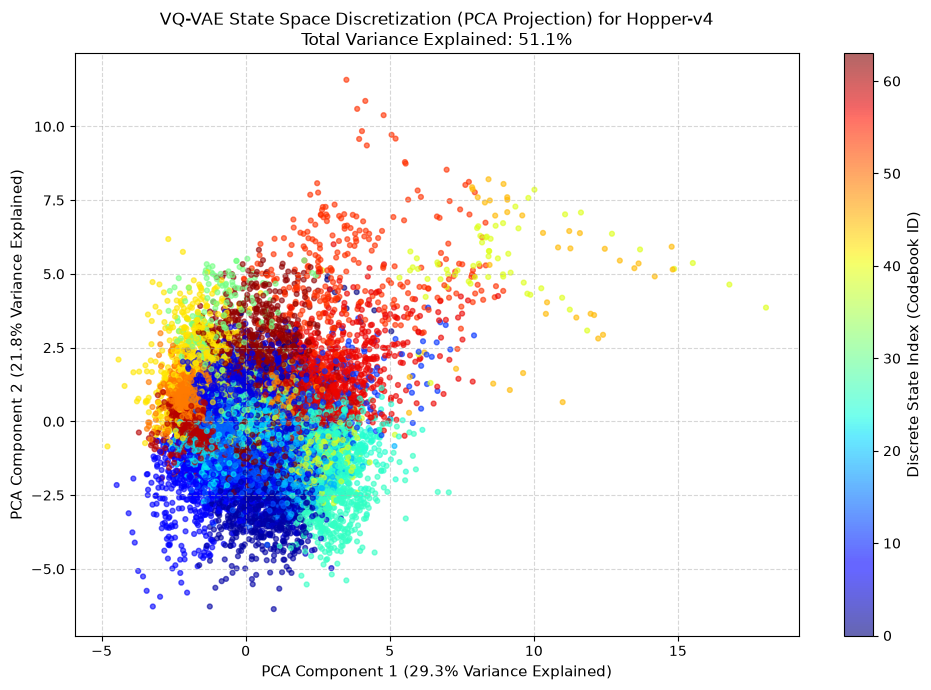

In [118]:
vqvae_model.eval()
with torch.no_grad():
    states_norm_dev = states_normalized.to(device)
    discrete_indices = vqvae_model.encode_to_discrete(states_norm_dev).cpu().numpy()

print(f"Unique discrete state clusters used: {len(np.unique(discrete_indices))} out of {NUM_EMBEDDINGS}")

# ---------------------------------------------------------
# PCA Projection for State Space Visualization
# ---------------------------------------------------------
if states_np.shape[1] == 1:
    # Handle rare 1D state spaces
    pca_states = np.column_stack([states_np[:, 0], np.zeros_like(states_np[:, 0])])
    var_exp = [100.0, 0.0]
else:
    # Standardize data prior to PCA
    states_mean = np.mean(states_np, axis=0)
    states_std = np.std(states_np, axis=0)
    states_std[states_std == 0] = 1.0  # Prevent division by zero
    states_centered = (states_np - states_mean) / states_std

    # Compute PCA via Singular Value Decomposition (SVD)
    U, S, Vt = np.linalg.svd(states_centered, full_matrices=False)
    pca_states = states_centered @ Vt[:2].T  # Project onto top 2 Principal Components

    # Calculate percentage of variance explained
    explained_variance = (S**2) / (len(states_np) - 1)
    total_variance = np.sum(explained_variance)
    var_exp = (explained_variance[:2] / total_variance) * 100

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_states[:, 0], 
    pca_states[:, 1], 
    c=discrete_indices, 
    cmap='jet', 
    alpha=0.6, 
    s=12
)

cbar = plt.colorbar(scatter)
cbar.set_label('Discrete State Index (Codebook ID)', fontsize=11)

plt.xlabel(f'PCA Component 1 ({var_exp[0]:.1f}% Variance Explained)', fontsize=11)
plt.ylabel(f'PCA Component 2 ({var_exp[1]:.1f}% Variance Explained)', fontsize=11)
plt.title(f'VQ-VAE State Space Discretization (PCA Projection) for {ENV_NAME}\nTotal Variance Explained: {sum(var_exp[:2]):.1f}%', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


### Cell 6: Action Masking Analysis to Maintain Discrete State (Self-Loop Actions)

REPLAY BUFFER DISCRETE TRANSITION ANALYSIS (Hopper-v4)
Total Trajectory Transitions (s_t -> s_{t+1}): 25,000
Self-Loop Transitions (z(s_t) == z(s_{t+1})): 14,954 (59.82%)
State-Changing Transitions (z(s_t) != z(s_{t+1})): 10,046 (40.18%)


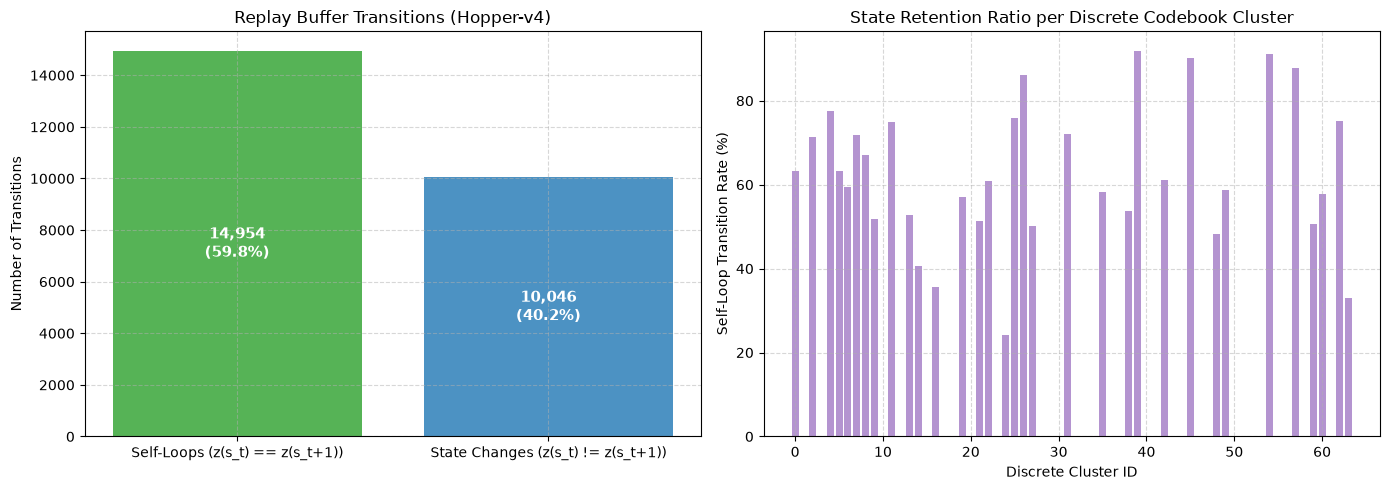

In [ ]:
# ---------------------------------------------------------
# 1. Normalize Replay Buffer (states & next_states)
# ---------------------------------------------------------
next_states_np = np.array(next_states, dtype=np.float32)

states_tensor = torch.tensor(states_np, dtype=torch.float32)
next_states_tensor = torch.tensor(next_states_np, dtype=torch.float32)

# Normalize using dataset stats
states_norm = (states_tensor - state_mean) / state_std
next_states_norm = (next_states_tensor - state_mean) / state_std

# ---------------------------------------------------------
# 2. Encode Transitions (s_t -> z_t) and (s_{t+1} -> z_{t+1})
# ---------------------------------------------------------
vqvae_model.eval()
with torch.no_grad():
    states_disc = vqvae_model.encode_to_discrete(states_norm.to(device)).cpu().numpy()
    next_states_disc = vqvae_model.encode_to_discrete(next_states_norm.to(device)).cpu().numpy()

# ---------------------------------------------------------
# 3. Transition Breakdown Analysis
# ---------------------------------------------------------
total_transitions = len(states_disc)
is_self_loop = (states_disc == next_states_disc)

num_self_loops = np.sum(is_self_loop)
num_state_changes = total_transitions - num_self_loops

self_loop_pct = (num_self_loops / total_transitions) * 100
state_change_pct = (num_state_changes / total_transitions) * 100

print("="*60)
print(f"REPLAY BUFFER DISCRETE TRANSITION ANALYSIS ({ENV_NAME})")
print("="*60)
print(f"Total Trajectory Transitions (s_t -> s_{{t+1}}): {total_transitions:,}")
print(f"Self-Loop Transitions (z(s_t) == z(s_{{t+1}})): {num_self_loops:,} ({self_loop_pct:.2f}%)")
print(f"State-Changing Transitions (z(s_t) != z(s_{{t+1}})): {num_state_changes:,} ({state_change_pct:.2f}%)")
print("="*60)

# ---------------------------------------------------------
# 4. Cluster-level Self-Loop & Action Masking Statistics
# ---------------------------------------------------------
unique_clusters, cluster_counts = np.unique(states_disc, return_counts=True)

cluster_self_loop_counts = np.zeros(NUM_EMBEDDINGS, dtype=int)
cluster_total_counts = np.zeros(NUM_EMBEDDINGS, dtype=int)

for cluster_id in range(NUM_EMBEDDINGS):
    cluster_mask = (states_disc == cluster_id)
    cluster_total_counts[cluster_id] = np.sum(cluster_mask)
    if cluster_total_counts[cluster_id] > 0:
        cluster_self_loop_counts[cluster_id] = np.sum(is_self_loop[cluster_mask])

# Self-loop ratio per cluster (Action Masking potential)
active_clusters = cluster_total_counts > 0
self_loop_ratios = np.zeros(NUM_EMBEDDINGS)
self_loop_ratios[active_clusters] = (cluster_self_loop_counts[active_clusters] / cluster_total_counts[active_clusters]) * 100

# ---------------------------------------------------------
# 5. Diagnostic Plots
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Self-Loop vs State-Change Distribution
axes[0].bar(['Self-Loops (z(s_t) == z(s_t+1))', 'State Changes (z(s_t) != z(s_t+1))'], 
            [num_self_loops, num_state_changes], color=['tab:green', 'tab:blue'], alpha=0.8)
axes[0].set_ylabel('Number of Transitions')
axes[0].set_title(f'Replay Buffer Transitions ({ENV_NAME})')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Add counts on top of bars
for bar in axes[0].patches:
    axes[0].annotate(f"{int(bar.get_height()):,}\n({bar.get_height()/total_transitions*100:.1f}%)",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Plot 2: Per-Cluster Self-Loop Rate (Action Retention Density)
active_cluster_ids = np.where(active_clusters)[0]
axes[1].bar(active_cluster_ids, self_loop_ratios[active_cluster_ids], color='tab:purple', alpha=0.7)
axes[1].set_xlabel('Discrete Cluster ID')
axes[1].set_ylabel('Self-Loop Transition Rate (%)')
axes[1].set_title('State Retention Ratio per Discrete Codebook Cluster')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
